In [1]:
import warnings
warnings.filterwarnings('ignore')

from dualneuron.twins.nets import load_model
from dualneuron.synthesis.ascend import fourier_ascending
from dualneuron.synthesis.visualize import blend

from tqdm import tqdm
import matplotlib.pyplot as plt
import torch
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
function = load_model(
    architecture='v1', 
    layer=None, 
    ensemble=False, 
    centered=True, 
    untrained=False,
    device='cuda'
)

In [ ]:
lei_results = []
mei_results = []
neuron = 4

for _ in range(5):
    result = fourier_ascending(
        lambda x: -torch.mean(function(x)[:, neuron]),
        magnitude_path='natural_gray.npy',
        image_size=None,
        init_image=None,
        total_steps=128,
        learning_rate=0.3,
        lr_schedule=True,
        eta_min=0.0,
        noise=0.0,
        values_range=(-2.0, 2.0),
        range_fn='tanh',
        nb_crops=8,
        box_size=(1.0, 1.0),
        target_norm=16.0,
        tv_weight=0.0,
        jitter_std=0.1,
        oversample=1, 
        reflect_pad_frac=0.05,
        device='cuda',
        verbose=True,
        save_all_steps=True,
    )
    lei_results.append(result)

    result = fourier_ascending(
        lambda x: torch.mean(function(x)[:, neuron]),
        magnitude_path='natural_gray.npy',
        image_size=None,
        init_image=None,
        total_steps=128,
        learning_rate=0.3,
        lr_schedule=True,
        eta_min=0.0,
        noise=0.0,
        values_range=(-2.0, 2.0),
        range_fn='tanh',
        nb_crops=8,
        box_size=(1.0, 1.0),
        target_norm=16.0,
        tv_weight=0.0,
        jitter_std=0.1,
        oversample=1, 
        reflect_pad_frac=0.1,
        device='cuda',
        verbose=True,
        save_all_steps=True,
    )
    mei_results.append(result)

Activation: 2.4076:   0%|          | 0/128 [00:00<?, ?it/s]

Activation: 4.3827: 100%|██████████| 128/128 [00:02<00:00, 50.38it/s]


In [199]:
lei_poles = []

for result in lei_results:
    image = result['image'][-1]
    alpha = result['alpha'][-1]
    pole = blend(image, alpha, alphacut=90.0, boost=1., bg_value=0.0)
    lei_poles.append(pole)

mei_poles = []

for result in mei_results:
    image = result['image'][-1]
    alpha = result['alpha'][-1]
    pole = blend(image, alpha, alphacut=90.0, boost=1., bg_value=0.0)
    mei_poles.append(pole)

In [200]:
lei_poles = np.stack(lei_poles)
mei_poles = np.stack(mei_poles)

np.save(f'lei_{neuron}_gray_poles.npy', lei_poles)
np.save(f'mei_{neuron}_gray_poles.npy', mei_poles)

In [201]:
import os
from dotenv import load_dotenv

load_dotenv()
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

from dualneuron.screening.visualize import plot_neuron_poles
from dualneuron.screening.sets import ImagenetImages
from pathlib import Path
import dualneuron

token = os.getenv("HF_TOKEN")
data_dir = os.getenv("DATA_DIR")

architecture = 'v1'
layer = None
dataset = "imagenet"

package_dir = Path(dualneuron.__file__).parent
mask_path = package_dir / "twins" / "V1GrayTaskDriven" / "mask.npy"
mask = np.load(mask_path)

In [42]:
dset = ImagenetImages(
    data_dir=data_dir + "datasets",
    token=token,
    split='train',
    use_center_crop=True,
    use_resize_output=True,
    use_grayscale=True,
    use_normalize=False,
    use_mask=True,
    use_crop_to_mask=True,
    use_norm=False,
    use_clip=False,
    mask=mask,
    num_channels=1,
    output_size=(224, 224),
    crop_size=236,
    bg_value=0.0,
    clip_max=1.0,
    clip_min=0.0,
    crop_padding_frac=0.02,
    norm=None    
)

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/267 [00:00<?, ?it/s]

In [202]:
layer_name = layer if layer is not None else "output"
idx_dir = data_dir + f"dryad/{architecture}_{layer_name}_{dataset}_ordered_indices"
resp_dir = data_dir + f"dryad/{architecture}_{layer_name}_{dataset}_ordered_responses"
num_neurons = len([f for f in os.listdir(resp_dir) if f.endswith('.npy')])
print(f"Number of .npy files in resp_dir: {num_neurons}")

Number of .npy files in resp_dir: 445


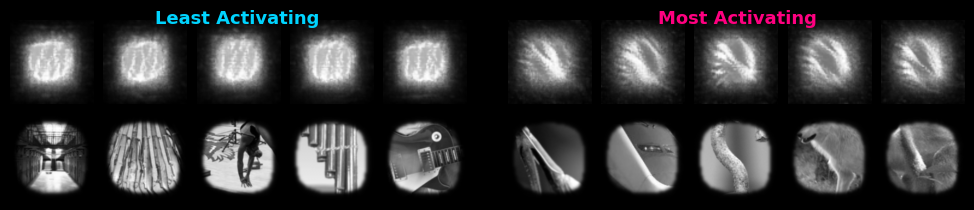

In [203]:
from dualneuron.screening.visualize import plot_synthesized_poles

plot_synthesized_poles(
    [neuron],
    dset,
    resp_dir,
    idx_dir,
    mask,
    lei_path=f'lei_{neuron}_gray_poles.npy',
    mei_path=f'mei_{neuron}_gray_poles.npy',
    output_file=f'neuron_{neuron}_gray_poles.png',
    figsize=None,
    vmin=None, 
    vmax=None,
    output_size=(224, 224),
    crop_padding_frac=0.15,
    add_neuron_labels=False
)

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import os
import cv2


def generate_neuron_mp4(
    neuron_id,
    dset,
    resp_dir,
    idx_dir,
    num_samples=100,
    savename='neuron_activation.mp4',
    fps=5,
    dpi=150,
    image_size=3.2,
    plot_size=(6, 4),
):
    print("Loading data...")
    sorted_responses = np.load(os.path.join(resp_dir, f"{neuron_id}.npy")).astype(np.float64) * 10.0
    sorted_dataset_indices = np.load(os.path.join(idx_dir, f"{neuron_id}.npy"))
    print(f"Response range: {sorted_responses.min():.2f} to {sorted_responses.max():.2f} Hz")
    
    # Adaptive sampling
    rng = np.random.default_rng(seed=num_samples)
    diffs = np.abs(np.diff(sorted_responses))
    probs = diffs / np.sum(diffs)
    sampled_transitions = rng.choice(len(probs), num_samples, p=probs, replace=False)
    sampled_positions = np.sort(sampled_transitions + 1)
    sampled_dataset_idx = sorted_dataset_indices[sampled_positions]
    sampled_activations = sorted_responses[sampled_positions]
    
    # Downsample curve
    n_total = len(sorted_responses)
    max_curve_points = 1000
    if n_total > max_curve_points:
        curve_indices = np.linspace(0, n_total - 1, max_curve_points, dtype=int)
        curve_responses = sorted_responses[curve_indices]
        curve_positions = curve_indices
    else:
        curve_responses = sorted_responses
        curve_positions = np.arange(n_total)
    
    global_min, global_max = 0, sorted_responses.max()
    
    # Precompute all colors
    def get_color(value):
        t = (value - global_min) / (global_max - global_min) if global_max > global_min else 0
        return (t, (1-t)*0.83, 1 - t*0.5)
    
    sample_colors = np.array([get_color(a) for a in sampled_activations])
    points = np.column_stack([curve_positions, curve_responses])
    segments = np.stack([points[:-1], points[1:]], axis=1)
    curve_colors = [get_color((curve_responses[i] + curve_responses[i+1])/2) 
                   for i in range(len(curve_responses)-1)]
    
    # Preload all images
    print("Preloading images...")
    images = []
    for idx in sampled_dataset_idx:
        img_tensor, _ = dset[idx]
        img = img_tensor.permute(1, 2, 0).cpu().numpy()
        if img.shape[-1] == 1:
            img = img.squeeze(-1)
        images.append(img)
    
    # Setup figure with tight layout (no bbox_inches needed)
    plt.ioff()
    fig = plt.figure(figsize=(image_size + plot_size[0] + 0.5, max(image_size, plot_size[1])), 
                     facecolor='black', constrained_layout=True)
    gs = fig.add_gridspec(1, 2, width_ratios=[image_size, plot_size[0]], wspace=0.15)
    ax_img = fig.add_subplot(gs[0])
    ax_plot = fig.add_subplot(gs[1])
    

    
    # Initialize image artist
    im_artist = ax_img.imshow(images[0], cmap='gray' if images[0].ndim == 2 else None)
    ax_img.axis('off')
    ax_img.set_facecolor('#0a0a0a')
    
    # Updatable text artists
    badge = ax_img.text(0.5, -0.08, '', transform=ax_img.transAxes, fontsize=14, 
                        fontweight='bold', ha='center', va='top',
                        bbox=dict(boxstyle='round,pad=0.6', facecolor='#0a0a0a', 
                                 edgecolor='white', linewidth=2))
    counter = ax_img.text(0.5, 1.08, '', transform=ax_img.transAxes, fontsize=12, 
                          fontweight='500', ha='center', va='bottom', color=(1,1,1,0.6))
    
    # Static plot setup - add padding so scatter points aren't clipped
    x_pad = (n_total - 1) * 0.02
    y_pad = (global_max - global_min) * 0.05
    ax_plot.set_facecolor('#0a0a0a')
    ax_plot.set_xlim(-x_pad, n_total - 1 + x_pad)
    ax_plot.set_ylim(global_min - y_pad, global_max + y_pad)
    ax_plot.grid(True, alpha=0.1, linestyle='--', linewidth=1, color='white')
    ax_plot.spines['top'].set_visible(False)
    ax_plot.spines['right'].set_visible(False)
    for spine in ['left', 'bottom']:
        ax_plot.spines[spine].set_color((1, 1, 1, 0.8))
        ax_plot.spines[spine].set_linewidth(2)
    ax_plot.tick_params(colors=(1, 1, 1, 0.8), labelsize=10, width=2)
    ax_plot.set_xlabel('Sorted Image Index', color='white', fontsize=12, fontweight='600')
    ax_plot.set_ylabel('Activation (Hz)', color='white', fontsize=12, fontweight='600')
    ax_plot.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
    
    # Static line collection
    lc = LineCollection(segments, colors=curve_colors, linewidth=2.5)
    ax_plot.add_collection(lc)
    
    # Static dim points (all samples)
    ax_plot.scatter(sampled_positions, sampled_activations, c=sample_colors, s=80, alpha=0.4, zorder=3)
    
    # Dynamic scatter placeholders
    visited_scat = ax_plot.scatter([], [], s=100, alpha=0.85, zorder=4)
    glow1 = ax_plot.scatter([], [], s=800, alpha=0.2, zorder=5)
    glow2 = ax_plot.scatter([], [], s=400, alpha=0.4, zorder=5)
    current = ax_plot.scatter([], [], s=150, alpha=1.0, zorder=6, edgecolors='white', linewidths=2.5)
    
    # Get frame size
    fig.canvas.draw()
    w, h = fig.canvas.get_width_height()
    frame_width = w + (w % 2)
    frame_height = h + (h % 2)
    
    # Video writer
    for codec in ['avc1', 'mp4v', 'XVID']:
        fourcc = cv2.VideoWriter_fourcc(*codec)
        out = cv2.VideoWriter(savename, fourcc, fps, (frame_width, frame_height))
        if out.isOpened():
            print(f"Using {codec} codec")
            break
    if not out.isOpened():
        raise RuntimeError("Could not initialize video writer")
    
    print(f"Generating {num_samples} frames at {frame_width}x{frame_height}...")
    
    for i in range(num_samples):
        # Update image
        im_artist.set_data(images[i])
        if images[i].ndim == 2:
            im_artist.set_cmap('gray')
        
        # Update text
        color = sample_colors[i]
        badge.set_text(f'{sampled_activations[i]:.2f} Hz')
        badge.set_color(color)
        badge.get_bbox_patch().set_edgecolor(color)
        counter.set_text(f'Sample {i + 1} / {num_samples}')
        
        # Update visited points
        if i > 0:
            visited_scat.set_offsets(np.column_stack([sampled_positions[:i], sampled_activations[:i]]))
            visited_scat.set_facecolors(sample_colors[:i])
        
        # Update current point
        pos = np.array([[sampled_positions[i], sampled_activations[i]]])
        for scat in [glow1, glow2, current]:
            scat.set_offsets(pos)
            scat.set_facecolors([color])
        
        # Render directly from canvas
        fig.canvas.draw()
        frame = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
        frame = frame.reshape(h, w, 4)[:, :, :3]
        
        if (w, h) != (frame_width, frame_height):
            frame = cv2.resize(frame, (frame_width, frame_height))
        
        out.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))
        
        if (i + 1) % 50 == 0:
            print(f"  {i + 1}/{num_samples} frames...")
    
    out.release()
    plt.close(fig)
    plt.ion()
    
    print(f"Done! Saved to {savename}")
    print(f"File size: {os.path.getsize(savename) / (1024*1024):.2f} MB")

In [22]:
generate_neuron_mp4(
    neuron_id=18,
    dset=dset,
    resp_dir=resp_dir,
    idx_dir=idx_dir,
    num_samples=144,
    fps=5  # 5 fps = 200ms per frame
)

Loading data...
Response range: 6.87 to 82.24 Hz
Preloading images...


[ERROR:0@3727.220] global cap_ffmpeg_impl.hpp:3207 open Could not find encoder for codec_id=27, error: Encoder not found
[ERROR:0@3727.220] global cap_ffmpeg_impl.hpp:3285 open VIDEOIO/FFMPEG: Failed to initialize VideoWriter


Using mp4v codec
Generating 144 frames at 970x400...
  50/144 frames...
  100/144 frames...
Done! Saved to neuron_activation.mp4
File size: 1.32 MB
